### 使用ライブラリ

In [1]:
using Base: @kwdef
using Parameters: @unpack
using Plots
using LinearAlgebra
using Distributions, Random
using Dates
# using TimeSeries
using Statistics
using NPZ
# using SignalAnalysis
# using SpecialFunctions
using DifferentialEquations

using Base.Threads
Threads.nthreads()

include("freq_response.jl")
using .FreqResponse
include("generate_event.jl")
using .GenerateEvents
include("HodgkinHuxley.jl")
using .FreqResponse
include("AlphaSynapse.jl")
using .AlphaSynapse
include("DelayConnection.jl")
using .DelayConnection

### 信号生成

In [2]:
function simulate_ou_process(theta, μ, σ, dt, maxT, initial)
    """
    Generate frequencies from OrnsteinUhlenbeckProcess.
    
    # Arguments
    - `theta::Number`: 符号に依存する平均回帰 or モーメンタム
    - `μ::Number`: 長期的なドリフト
    - `σ::Number`: バラつき
    - `dt::Number`: time resolution (ms).
    - `maxT::Number`: Max time number.
    - `initial::Number`: Initial number.
    
    # Returns
    - `Array{Float32, maxT}`: The time-series of frequency.
    """
    p = Array{Float32}(undef, length(0:dt:maxT))
    p[1] = initial
    w = sigma * rand(Normal(), length(p)) * sqrt(dt)
    for i in 1:(length(p)-1)
        p[i+1] = p[i] + theta*(μ-p[i])*dt + w[i]
    end
    return p
end


simulate_ou_process (generic function with 1 method)

### Network定義

In [3]:
function intra_layer_update!(
    varr, noises, spikes, history, efficacy, neurons, synapses_gen, synapses_noise,
    synapses_exc, synapses_inh, t, input_weight, feedback_weight, feedback_weight_inh, 
    V_exc, Er, V_inh, dt, threshold, delay_exc_connection, delay_inh_connection
)
    # ここのシナプスモデルの出力は、mS/cm^2なのかどうか
    AlphaSynapse.Synaptic_update!(synapses_gen, synapses_gen.param, spikes, t)
    AlphaSynapse.Synaptic_update!(synapses_noise, synapses_gen.param, noises, t)
    gsyn_exc = input_weight * efficacy .* (synapses_gen.g_syn[:,t] .+ synapses_noise.g_syn[:,t])
    gsyn_exc .+= feedback_weight * efficacy .* synapses_exc.g_syn[:,t]
    gsyn_inh = feedback_weight_inh * synapses_inh.g_syn[:,t]
    # Ieは数μA/cm^2から数十μA/cm^2になることが望ましい
    Ie = ((gsyn_exc .* (V_exc-Er)) .+ (gsyn_inh .* (V_inh-Er)))
    HodgkinHuxley.rk_update!(neurons, neurons.param, Ie, dt)
    
    if t > 1
        post_fire = (varr[t-1, :] .< threshold) .& (neurons.v .> threshold)
        input_spikes1 = DelayConnection.Delay_Connection_call!(delay_exc_connection, collect(spikes.+noises .> 0)[:], UInt32(t))
        input_spikes2 = DelayConnection.Delay_Inh_Connection_call!(delay_inh_connection, collect(spikes.+noises .> 0)[:], UInt32(t))
        AlphaSynapse.Synaptic_update!(synapses_exc, synapses_exc.param, input_spikes1, t)
        AlphaSynapse.Synaptic_update!(synapses_inh, synapses_inh.param, input_spikes2, t)
    
        for j in 1:length(efficacy)
            if post_fire[j] > 0
                efficacy[j] = efficacy[j] * 0.5
            else
                efficacy[j] = minimum([efficacy[j] + 1e-4, 1])
            end
        end
    end
    
    return neurons.v, efficacy, Ie
end


function intra_layer(input_length, input_fire, noise_fire, params)
    # Define between layer
    delay_exc_connection = DelayConnection.Delay_Connection(
        params.Ne+params.Ni,
        2.0,
        params.T,
        params.dt
    )
    delay_inh_connection = DelayConnection.Delay_Inh_Connection(
        params.Ne+params.Ni,
        5.0,
        params.T,
        params.dt
    )
    neurons = HodgkinHuxley.HH{Float32}(N=params.Ne+params.Ni)
    synapses_gen = AlphaSynapse.Synapse{Float32}(Ne=params.Ne+params.Ni, Ni=0, T=params.T*1e-3, dt=params.dt*1e-3)
    synapses_noise = AlphaSynapse.Synapse{Float32}(Ne=1, Ni=0, T=params.T*1e-3, dt=params.dt*1e-3)
    synapses_exc = AlphaSynapse.Synapse{Float32}(Ne=params.Ne+params.Ni, Ni=0, T=params.T*1e-3, dt=params.dt*1e-3)
    synapses_inh = AlphaSynapse.Synapse{Float32}(Ne=0, Ni=params.Ne+params.Ni, T=params.T*1e-3, dt=params.dt*1e-3)
    #synapses_gen = AlphaSynapse.Synapse{Float32}(Ne=params.Ne+params.Ni, Ni=0, T=params.T, dt=params.dt)
    #synapses_noise = AlphaSynapse.Synapse{Float32}(Ne=1, Ni=0, T=params.T, dt=params.dt)
    #synapses_exc = AlphaSynapse.Synapse{Float32}(Ne=params.Ne+params.Ni, Ni=0, T=params.T, dt=params.dt)
    #synapses_inh = AlphaSynapse.Synapse{Float32}(Ne=0, Ni=params.Ne+params.Ni, T=params.T, dt=params.dt)
    
    varr = zeros(Float32, input_length, params.Ne+params.Ni)
    uarr = zeros(Float32, input_length, params.Ne+params.Ni)
    connect_exc = zeros(Float32, params.Ne+params.Ni, params.Ne+params.Ni)
    connect_inh = zeros(Float32, params.Ne+params.Ni, params.Ne+params.Ni)
    connect_input = zeros(Float32, params.Ne+params.Ni, params.Ne+params.Ni)

    for i in 1:params.Ne+params.Ni
        inh_list = rand(1:params.Ne+params.Ni, params.NiC)
        for ind in inh_list
            connect_inh[i,ind] += 1
        end
        exc_list = rand(setdiff(Set(collect(1:params.Ne+params.Ni)), Set(inh_list)), params.NeC)
        for ind in exc_list
            connect_exc[i,ind] += 1
        end
    end
    
    for i in 1:params.Ne+params.Ni
        input_list = rand(1:params.Ne+params.Ni, params.NiE)
        for ind in input_list
            connect_input[i,ind] += 1
        end
    end
    
    events = ones(Int, params.Ne+params.Ni)
    efficacy = ones(Float64, params.Ne+params.Ni)
    g_rand = rand(params.d, params.Ne+params.Ni, params.Ne+params.Ni)
    g_input = rand(params.d, params.Ne+params.Ni, params.Ne+params.Ni)
    g_noise = rand(params.d, params.Ne+params.Ni, params.Ne+params.Ni)
    surface = 4*pi*(20^2) * (params.Ne+params.Ni)
    input_weight = g_input ./ surface
    noise_weight = g_noise ./ surface
    feedback_weight = connect_exc .* g_rand ./ surface
    feedback_weight_inh = connect_inh .* 5 ./ surface
    
    # main loop
    @inbounds for i in 1:params.nt-1
        i = Int(i)
        varr[i, :], efficacy, uarr[i, :] = intra_layer_update!(
            varr, noise_fire[i,:], input_fire[i,:], events, efficacy, neurons, 
            synapses_gen, synapses_noise, synapses_exc, synapses_inh, i,
            input_weight, feedback_weight, feedback_weight_inh, params.V_exc, params.Er, params.V_inh, params.dt, params.threshold,
            delay_exc_connection, delay_inh_connection
        )
    end
    
    # Return firing
    # 前後で発火を判断してるので、得られる長さは最大長-1になることに注意
    fire = zeros(Float32, input_length, params.Ne+params.Ni)
    fire = (varr[1:Int(params.nt)-1, :] .< params.threshold) .& (varr[2:Int(params.nt), :] .> params.threshold)

    return uarr, Bool.(fire)
end



intra_layer (generic function with 1 method)

In [4]:
function between_layer_update!(
    varr, noises, spikes, history, efficacy, neurons, 
    synapses_gen, synapses_noise, synapses_exc, synapses_inh, synapses_basket_exc, synapses_basket_inh,
    t, delta, basket_neurons, basket_spikes, input_weight, feedback_weight, feedback_weight_inh,
    V_exc, Er, V_inh, dt, threshold, delay_exc_connection, delay_inh_connection, d, surface
)
    AlphaSynapse.Synaptic_update!(synapses_gen, synapses_gen.param, spikes, t)
    AlphaSynapse.Synaptic_update!(synapses_noise, synapses_gen.param, noises, t)
    AlphaSynapse.Synaptic_update!(synapses_basket_inh, synapses_basket_inh.param, basket_spikes, t)

    gsyn_exc = input_weight * efficacy .* (synapses_gen.g_syn[:,t] .+ synapses_noise.g_syn[:,t])
    gsyn_exc .+= feedback_weight * efficacy .* synapses_exc.g_syn[:,t]
    gsyn_inh = feedback_weight_inh * synapses_inh.g_syn[:,t]
    gsyn_inh .+= synapses_basket_inh.g_syn[:,t] .* 5 ./ surface

    Ie = ((gsyn_exc .* (V_exc-Er)) .+ (gsyn_inh .* (V_inh-Er)))
    HodgkinHuxley.rk_update!(neurons, neurons.param, Ie, dt)

    if t > 1
        post_fire = (varr[t-1, :] .< threshold) .& (neurons.v .> threshold)
        input_spikes1 = DelayConnection.Delay_Connection_call!(delay_exc_connection, collect(spikes.+noises .> 0)[:], UInt32(t))
        input_spikes2 = DelayConnection.Delay_Inh_Connection_call!(delay_inh_connection, collect(spikes.+noises .> 0)[:], UInt32(t))
        AlphaSynapse.Synaptic_update!(synapses_exc, synapses_exc.param, input_spikes1, t)
        AlphaSynapse.Synaptic_update!(synapses_inh, synapses_inh.param, input_spikes2, t)

        for j in 1:length(efficacy)
            if post_fire[j] > 0
                efficacy[j] = efficacy[j] * 0.5
            else
                efficacy[j] = minimum([efficacy[j] + 1e-4, 1])
            end
        end

        basket_fire_propagation_rate = Categorical([0.95, 0.05])
        filter_basket = (rand(basket_fire_propagation_rate, length(efficacy)).-1)
        pre_basket_fire = filter_basket .* post_fire
        AlphaSynapse.Synaptic_update!(synapses_basket_exc, synapses_basket_exc.param, pre_basket_fire, t)
        Ie_basket = Vector{Float32}([sum(synapses_basket_exc.g_syn[:,t] .* rand(d,1) ./ surface) .* (V_exc-Er)])
        HodgkinHuxley.rk_update!(basket_neurons, basket_neurons.param, Ie_basket, dt)
        basket_fire = (basket_neurons.v .> threshold) .& (varr[t-1, :] .< threshold)
    else
        basket_fire = 0
        Ie_basket = Vector{Float32}([0])
    end

    return neurons.v, efficacy, Ie, delta, Ie_basket, basket_fire
end

function between_layer(input_length, input_fire, noise_fire, params)
    # Initialize layer parameters
    delay_exc_connection = DelayConnection.Delay_Connection(
        UInt32(params.Ne+params.Ni),
        2.0,
        params.T,
        params.dt
    )
    delay_inh_connection = DelayConnection.Delay_Inh_Connection(
        UInt32(params.Ne+params.Ni),
        5.0,
        params.T,
        params.dt
    )
    neurons = HodgkinHuxley.HH{Float32}(N=params.Ne+params.Ni)
    synapses_gen = AlphaSynapse.Synapse{Float64}(Ne=params.Ne+params.Ni, Ni=0, T=params.T*1e-3, dt=params.dt*1e-3)
    synapses_noise = AlphaSynapse.Synapse{Float64}(Ne=1, Ni=0, T=params.T*1e-3, dt=params.dt*1e-3)
    synapses_exc = AlphaSynapse.Synapse{Float64}(Ne=params.Ne+params.Ni, Ni=0, T=params.T*1e-3, dt=params.dt*1e-3)
    synapses_inh = AlphaSynapse.Synapse{Float64}(Ne=0, Ni=params.Ne+params.Ni, T=params.T*1e-3, dt=params.dt*1e-3)
    
    varr = zeros(Float32, input_length, params.Ne+params.Ni)
    uarr = zeros(Float32, input_length, params.Ne+params.Ni)
    varr_basket = zeros(Float32, input_length, 1)
    uarr_basket = zeros(Float32, input_length, 1)
    connect_exc = zeros(Float32, params.Ne+params.Ni, params.Ne+params.Ni)
    connect_inh = zeros(Float32, params.Ne+params.Ni, params.Ne+params.Ni)
    connect_input = zeros(Float32, params.Ne+params.Ni, params.Ne+params.Ni)

    basket_neurons = HodgkinHuxley.HH{Float32}(N=1)
    synapses_basket_exc = AlphaSynapse.Synapse{Float64}(Ne=params.Ne+params.Ni, Ni=0, T=params.T*1e-3, dt=params.dt*1e-3)
    synapses_basket_inh = AlphaSynapse.Synapse{Float64}(Ne=0, Ni=1, T=params.T*1e-3, dt=params.dt*1e-3)

    for i in 1:params.Ne+params.Ni
        inh_list = rand(1:params.Ne+params.Ni, params.NiC)
        for ind in inh_list
            connect_inh[i,ind] += 1
        end
        exc_list = rand(setdiff(Set(collect(1:params.Ne+params.Ni)),Set(inh_list)), params.NeC)
        for ind in exc_list
            connect_exc[i,ind] += 1
        end
    end
    
    events = ones(Int, params.Ne+params.Ni)
    efficacy = ones(Float64, params.Ne+params.Ni)
    g_rand = rand(params.d, params.Ne+params.Ni, params.Ne+params.Ni)
    g_input = rand(params.d, params.Ne+params.Ni, params.Ne+params.Ni)
    g_noise = rand(params.d, params.Ne+params.Ni, params.Ne+params.Ni)
    surface = 4*pi*(20^2) * (params.Ne+params.Ni)  # 全体の影響を評価してるので、今回設定してる100個の細胞だけ掛け算する
    input_weight = g_input ./ surface
    noise_weight = g_noise ./ surface
    feedback_weight = connect_exc .* g_rand ./ surface
    feedback_weight_inh = connect_inh .* 5 ./ surface

    fire_propagation_rate = Categorical([0.3, 0.7])
    filter_connect = (rand(fire_propagation_rate, params.Ne+params.Ni, params.Ne+params.Ni).-1)
    delta = 1.0
    basket_fire = 0

    # Main loop
    @inbounds for i = 1:params.nt-1
        filter_spike = filter_connect * input_fire[i,:]
        filter_spike = isone.(ifelse.(filter_spike .> 0, 1, 0))
        varr[i, :], efficacy, uarr[i, :], delta, uarr_basket[i, :], basket_fire = between_layer_update!(
            varr, noise_fire[i,:], filter_spike, events, efficacy, neurons,
            synapses_gen, synapses_noise, synapses_exc, synapses_inh, synapses_basket_exc, synapses_basket_inh,
            i, delta, basket_neurons, basket_fire, input_weight, feedback_weight, feedback_weight_inh,
            params.V_exc, params.Er, params.V_inh, params.dt, params.threshold, delay_exc_connection, delay_inh_connection, params.d, surface
        )
    end

    # Return firing
    fire = (varr[1:Int(params.nt)-1, :] .< params.threshold) .& (varr[2:Int(params.nt), :] .> params.threshold)
    # return Bool.(fire), uarr_basket
    return Bool.(fire)
end


between_layer (generic function with 1 method)

In [5]:
4*pi*(20^2)

5026.548245743669

### メイン処理

In [6]:
@kwdef mutable struct SimulationParams
    Ne::Int = 80
    Ni::Int = 20
    NiC::Int = 30
    NeC::Int = 1
    NiE::Int = 100
    T::Float64 = 1600.0
    dt::Float64 = 0.05
    V_exc::Float64 = 0.0
    Er::Float64 = -70.0
    V_inh::Float64 = -65.0
    threshold::Float64 = 40.0
    nt::Int = 0
    d::Any = Normal(1.0, 0.5)
end

function SimulationParams(; Ne, Ni, NiC, NeC, NiE, T, dt, V_exc, Er, V_inh, threshold, d)
    nt = Int(T / dt)  # nt を T/dt で計算
    return SimulationParams(Ne, Ni, NiC, NeC, NiE, T, dt, V_exc, Er, V_inh, threshold, nt, d)
end

params = SimulationParams(
    Ne=100,
    Ni=0,
    NeC=1,
    NiC=30,
    NiE=100,
    T=1600.0,
    dt=0.05,
    V_exc=.0,
    Er=-65.0,
    V_inh=-70.0,
    threshold=-40.0,
    d=Normal(1.0, 0.5)
)

SimulationParams(100, 0, 30, 1, 100, 1600.0, 0.05, 0.0, -65.0, -70.0, -40.0, 32000, Normal{Float64}(μ=1.0, σ=0.5))

In [14]:
using Base.Threads

run_path=100

neuron_count = params.Ne + params.Ni

fire1 = zeros(Bool, params.nt, neuron_count, run_path);
fire2 = zeros(Bool, params.nt, neuron_count, run_path);
fire3 = zeros(Bool, params.nt, neuron_count, run_path);
fire4 = zeros(Bool, params.nt, neuron_count, run_path);
fire5 = zeros(Bool, params.nt, neuron_count, run_path);
u_basket = zeros(Float32, params.nt, 1, run_path);

SIGNAL_WIDTH = 10.0
DIFF_F = 200.0
# dt_signal, num_digits = params.dt*1e-3, 5;
dt_signal = params.dt*1e-3;

@time Threads.@threads for j = 1:1:run_path
    # 乱数はスレッド内で定義しないと固定になって同じ結果が出力され続けるので注意
    rng = MersenneTwister()  # 各スレッドに個別のRNGを生成
    seed = rand(rng, 1:10^6)  # ランダムシードを生成
    Random.seed!(rng, seed)   # シードを設定
    # results[i] = rand(rng)    # 乱数を生成して保存

    freq = InputFreqSetting(Fs=1/params.dt,StopTime=params.T,Width=SIGNAL_WIDTH,f_diff=DIFF_F,f_exc=100.0,mid_point=800.0,f_inh=100.0);
    inputs, currents, noises = step_freq_response(freq);
    
    pre_spikes, b_spikes = generate_events_tonic(inputs, noises, dt_signal, neuron_count)
    uarr, fire1[1:end-1,:,j] = intra_layer(length(inputs), pre_spikes, b_spikes, params)
    # println(uarr);
    #fire1[1:end-2,:,j], u_basket[1:end, :, j] = between_layer(length(inputs), pre_spikes, b_spikes)

    _, b_spikes = generate_events_tonic(inputs, noises, dt_signal, neuron_count)
    fire2[1:end-1,:,j] = between_layer(length(inputs), fire1[:,:,j], b_spikes, params)
    
    _, b_spikes = generate_events_tonic(inputs, noises, dt_signal, neuron_count)
    fire3[1:end-1,:,j] = between_layer(length(inputs), fire2[:,:,j], b_spikes, params)

    _, b_spikes = generate_events_tonic(inputs, noises, dt_signal, neuron_count)
    fire4[1:end-1,:,j] = between_layer(length(inputs), fire3[:,:,j], b_spikes, params)

    _, b_spikes = generate_events_tonic(inputs, noises, dt_signal,  neuron_count)
    fire5[1:end-1,:,j] = between_layer(length(inputs), fire4[:,:,j], b_spikes, params)
end

  0.003768 seconds (344.11 k allocations: 14.769 MiB)
  0.004188 seconds (371.23 k allocations: 15.185 MiB)
  0.004343 seconds (381.65 k allocations: 15.474 MiB)
  0.004559 seconds (404.64 k allocations: 16.071 MiB)
  0.005818 seconds (154.66 k allocations: 9.884 MiB)
  0.003411 seconds (136.70 k allocations: 7.830 MiB)
  0.005843 seconds (160.56 k allocations: 33.998 MiB)
  0.005058 seconds (192.09 k allocations: 8.196 MiB)
  0.005561 seconds (115.47 k allocations: 5.840 MiB)
  0.003694 seconds (111.23 k allocations: 17.397 MiB)
  0.003495 seconds (136.16 k allocations: 30.344 MiB)
  0.003264 seconds (210.95 k allocations: 8.399 MiB)
  0.012141 seconds (125.75 k allocations: 6.906 MiB)
  0.003440 seconds (138.25 k allocations: 7.982 MiB)
  0.003529 seconds (124.44 k allocations: 14.728 MiB)
  0.003677 seconds (126.65 k allocations: 15.005 MiB)
  0.003489 seconds (138.47 k allocations: 8.217 MiB)
  0.003456 seconds (127.97 k allocations: 6.928 MiB)
  0.003857 seconds (116.68 k allocati

In [15]:
# true になっている場所のインデックスをすべて取得
indices_list = findall(x -> x == true, fire1)

# save output
using Serialization

# バイナリファイルに保存
open("fire1.bin", "w") do file
    serialize(file, indices_list)
end

2520696

In [16]:
# true になっている場所のインデックスをすべて取得
indices_list = findall(x -> x == true, fire5)

# save output
using Serialization

# バイナリファイルに保存
open("fire5.bin", "w") do file
    serialize(file, indices_list)
end

6095856

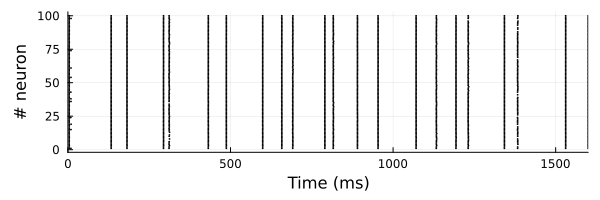

In [19]:
# 例えば試行回数がn番目の試行に対応するインデックスを抽出する
target_trial = 2
indices_list = findall(x -> x == true, fire5)
filtered_indices = filter(x -> x[3] == target_trial, indices_list)

resolution = 1/params.dt

# 抽出したインデックスからラスタープロットのデータを準備
spike_times = [x[1] for x in filtered_indices]./resolution  # 時間軸のデータ
neuron_ids = [x[2] for x in filtered_indices]       # 試行番号

# ラスタープロットを作成
scatter(
    spike_times, neuron_ids, xlabel="Time (ms)", ylabel="# neuron", legend=false,
    markersize=1, color="black", size=(600,200), xlim=(0,1600),
    left_margin = 5Plots.mm, bottom_margin = 5Plots.mm
)

  0.008907 seconds (96.05 k allocations: 3.845 MiB)


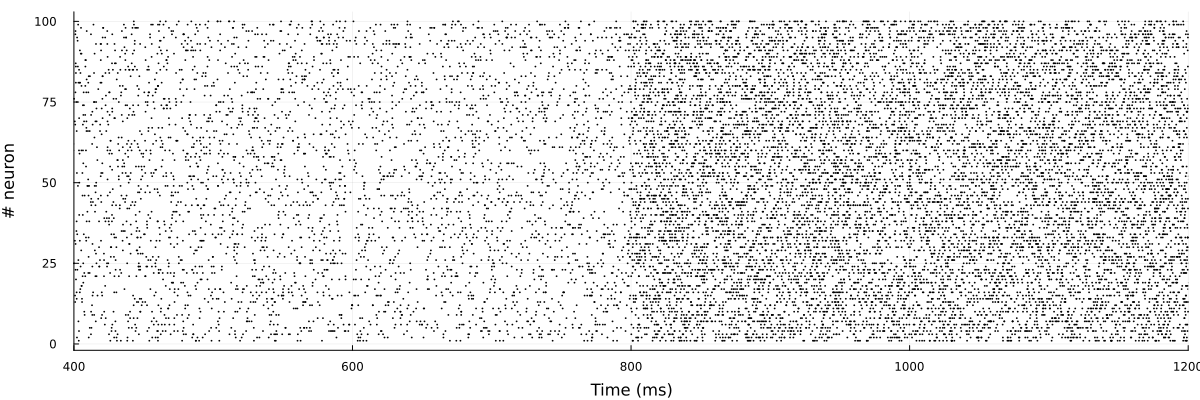

In [89]:
SIGNAL_WIDTH = 10.0
DIFF_F = 200.0
dt_signal = params.dt*1e-3;

freq = InputFreqSetting(Fs=1/params.dt,StopTime=params.T,Width=SIGNAL_WIDTH,f_diff=DIFF_F,f_exc=100.0,mid_point=800.0,f_inh=100.0);
inputs, currents, noises = step_freq_response(freq);
    
pre_spikes, b_spikes = generate_events_tonic(inputs, noises, dt_signal, neuron_count)
indices_list = findall(x -> x == true, pre_spikes)

# 例えば試行回数がn番目の試行に対応するインデックスを抽出する
target_trial = 1
# filtered_indices = filter(x -> x[2] == target_trial, indices_list)
filtered_indices = indices_list

resolution = 1/params.dt

# 抽出したインデックスからラスタープロットのデータを準備
spike_times = [x[1] for x in filtered_indices]./resolution  # 時間軸のデータ
neuron_ids = [x[2] for x in filtered_indices]       # 試行番号

# ラスタープロットを作成
scatter(
    spike_times, neuron_ids, xlabel="Time (ms)", ylabel="# neuron", legend=false,
    markersize=1, color="black", size=(1200,400), xlim=(400,1200),
    left_margin = 5Plots.mm, bottom_margin = 5Plots.mm
)

In [64]:
using Serialization

# バイナリファイルに保存
indices_list = deserialize("fire1.bin");

In [65]:
using Base: @kwdef
using Parameters: @unpack

@kwdef mutable struct GammaParams
    Ne::Int = 80
    Ni::Int = 20
    N_count::Int = 0
    # Initial Setting.
    Tmin::Float64 = 400.0
    Tmax::Float64 = 800.0
    dt::Float64 = 0.05
    npts::Int64 = 0
    # Space
    xmax::Float64 = 0.2
    ymax::Float64 = 0.2
    X::Vector
    Y::Vector
    xe::Float64 = 0.0
    ye::Float64 = 0.0
    # Parameter
    va::Float64 = 200.0  # axonal velocity (mm/sec)
    lambda::Float64 = 0.2  # space constant (mm)
    dur::Float64 = 100.0  # total duration of LFP waveform
    nlfp::Int64 = 0  # nb of LFP pts

    sig_e::Float64 = 0.0  # std-dev for excitation
    sig_i::Float64 = 2.1  # std-dev of ihibition (in ms)
    
    amp_e::Float64 = 0.0
    amp_i::Float64 = 0.0

    s_e::Float64 = 0.0
    s_i::Float64 = 0.0
    end

function GammaParams(; layer_name, Ne, Ni, Tmin, Tmax, dt, xmax, ymax, va, lambda, dur, sig_i)
    N_count = Ne + Ni
    npts = Int(Tmax / dt)  # nt を T/dt で計算
    X = rand(N_count) * xmax  # coordinates
    Y = rand(N_count) * ymax  # coordinates
    xe = xmax / 2  # coordinates of electrode
    ye = ymax / 2  # coordinates of electrode

    # Kernel
    nlfp = Int(dur / dt)
    sig_e = 1.5 * sig_i

    if layer_name == "deep"
        amp_e = -0.16
        amp_i = -0.2
    elseif layer_name == "soma"
        amp_e = 0.48
        amp_i = 3
    elseif layer_name == "superficial"
        amp_e = 0.24
        amp_i = -1.2
    elseif layer_name == "surface"
        amp_e = -0.08
        amp_i = 0.3
    else
        amp_e = 0.7  # uLFP amplitude for exc cells
        amp_i = -3.4  # uLFP amplitude for inh cells
    end

    s_e = 2 * sig_e * sig_e
    s_i = 2 * sig_i * sig_i
    
    return GammaParams(
        Ne,
        Ni,
        N_count,
        Tmin,
        Tmax,
        dt,
        npts,
        xmax,
        ymax,
        X,
        Y,
        xe,
        ye,
        va,
        lambda,
        dur,
        nlfp,
        sig_e,
        sig_i,
        amp_e,
        amp_i,
        s_e,
        s_i
    )
end

lfp_params = GammaParams(
    layer_name = "deep",
    Ne=80,
    Ni=20,
    Tmin=400.0,
    Tmax=800.0,
    dt=0.05,
    xmax=0.2,
    ymax=0.2,
    va=200.0,
    lambda=0.2,
    dur=100.0,
    sig_i=2.1
)

GammaParams(80, 20, 100, 400.0, 800.0, 0.05, 16000, 0.2, 0.2, [0.028684368023218054, 0.03861410584796148, 0.09003336942959834, 0.03339212538636847, 0.060476414763351416, 0.06134387243548561, 0.14042285243369507, 0.042678751531919495, 0.029267064437819502, 0.013458773322663764  …  0.18300865585143702, 0.034958185391194954, 0.08171666344604951, 0.1323407735454818, 0.11026668892399977, 0.06746191271469433, 0.028460025081454423, 0.07520449579313226, 0.15224028430102599, 0.08193265647250692], [0.0493196488911124, 0.030586311227394792, 0.16623849200379637, 0.11551633798559842, 0.06972233371592287, 0.12562953545812364, 0.13069697098461294, 0.06975063409086098, 0.1187310790798924, 0.05043063591465331  …  0.09126599892244602, 0.021041089793885373, 0.0992282596773509, 0.07130738535434145, 0.06423878881116685, 0.006805957516374761, 0.17116198594559207, 0.033613262875023996, 0.046207193820310424, 0.17353343198423432], 0.1, 0.1, 200.0, 0.2, 100.0, 2000, 3.1500000000000004, 2.1, -0.16, -0.2, 19.8450

- Neの数はexcの対応
- Niの数はinhの対応

In [66]:
using DelimitedFiles
using Random
using LinearAlgebra


function f_temporal_kernel(t, tau)
    """カーネルの時間的な部分を定義する関数"""
    return exp.(-(t .^ 2) ./ tau)
end

function calc_lfp(cells, params, run_path)
    dist = sqrt.((params.X .- params.xe) .^ 2 .+ (params.Y .- params.ye) .^ 2)  # 電極までの距離 (mm)
    delay = 10.4 .+ dist ./ params.va  # ピークまでの遅延時間 (ms)
    amp = exp.(-dist ./ params.lambda)
    amp[1:params.Ne] .*= params.amp_i
    amp[params.Ne+1:end] .*= params.amp_e
    
    lfp_time = collect(0:params.npts-1) .* params.dt
    """セルからLFPを計算する"""
    spt = [index[1]*params.dt - params.Tmin for index in cells] 
    cid = [index[2] for index in cells]

    println(size(amp[cid]))
    println(params.s_i)
    # カーネルの寄与を計算
    kernel_contribs = amp[cid]' .* f_temporal_kernel(lfp_time[:] .- delay[cid]' .- spt', params.s_i)
    
    # 各LFPポイントに対する寄与を合計してLFPを計算
    lfp = sum(kernel_contribs, dims=2) ./ 3
    return lfp
end



calc_lfp (generic function with 1 method)

In [67]:
# フィルタリング条件の定義
lower_bound = lfp_params.Tmin / lfp_params.dt
upper_bound = (lfp_params.Tmin + lfp_params.Tmax) / lfp_params.dt

# 条件に合致するインデックスのみを採用
filtered_indices = filter(index -> lower_bound <= index[1] <= upper_bound, indices_list)


lfp = calc_lfp(filtered_indices, lfp_params, 1);

(574,)
8.82


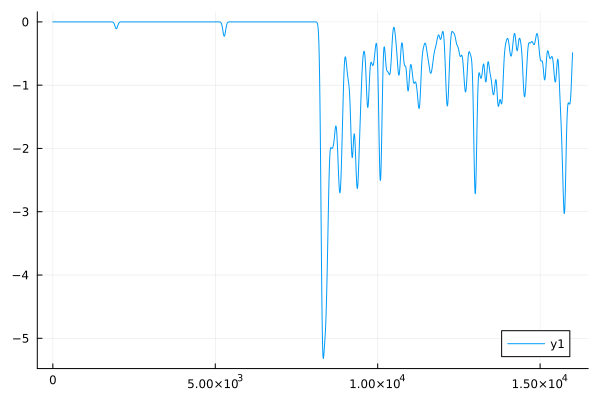

In [68]:
using Plots
plot(lfp)